# Optimisation des tournées de livraison — TSP
**Projet CesiCDP — Réponse à l'appel ADEME**

Ce notebook regroupe :
1. La **modélisation formelle** du problème
2. L'**étude de complexité** (NP-complétude)
3. Des **exemples de code Python** exécutables (vérificateur, force brute, Held-Karp, plus proche voisin, benchmark)


---
# 1. Modélisation formelle du problème

## 1.1 Contexte
Dans le cadre de l'appel à projet ADEME, l'objectif est d'optimiser les tournées de livraison afin de **réduire les déplacements et la consommation énergétique des véhicules**.

## 1.2 Définition du graphe
Le problème est modélisé par un graphe pondéré :
$$G = (V, E, w)$$

- $V$ : ensemble des sommets (villes + dépôt)
- $E$ : ensemble des arêtes
- $w$ : fonction de poids (temps de trajet)

On note $V = \{v_0, v_1, \dots, v_n\}$ où $v_0$ est le dépôt.

## 1.3 Graphe complet et hypothèse
On considère un **graphe complet** : chaque arête représente le **plus court chemin réel** entre deux villes via le réseau routier.

## 1.4 Propriété métrique
Le TSP étudié est **métrique** :
- Positivité : $w(i,j) \geq 0$
- Symétrie : $w(i,j) = w(j,i)$
- Inégalité triangulaire : $w(i,k) \leq w(i,j) + w(j,k)$

## 1.5 Fonction objectif
On cherche une **tournée hamiltonienne minimale**. Si $\pi$ est une permutation des sommets :
$$C(\pi) = \sum_{k=0}^{n-1} w(\pi_k, \pi_{k+1}) + w(\pi_n, \pi_0)$$

Le problème : $\min_{\pi} C(\pi)$

## 1.6 Représentation en mémoire
On utilise une **matrice d'adjacence pondérée** $M[i][j] = w(v_i, v_j)$ : accès en $O(1)$, adapté aux graphes denses.


### Exemple : génération d'un graphe métrique aléatoire

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def generer_graphe_metrique(n, taille=100):
    """Génère n villes aléatoires dans un carré et renvoie (coords, matrice des distances)."""
    coords = np.random.rand(n, 2) * taille
    M = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1)
    return coords, M

coords, M = generer_graphe_metrique(8)
print("Coordonnées des villes :")
print(coords.round(2))
print("\nMatrice des distances (extrait 5x5) :")
print(M[:5, :5].round(2))

Coordonnées des villes :
[[37.45 95.07]
 [73.2  59.87]
 [15.6  15.6 ]
 [ 5.81 86.62]
 [60.11 70.81]
 [ 2.06 96.99]
 [83.24 21.23]
 [18.18 18.34]]

Matrice des distances (extrait 5x5) :
[[ 0.   50.17 82.42 32.76 33.2 ]
 [50.17  0.   72.64 72.51 17.06]
 [82.42 72.64  0.   71.69 70.92]
 [32.76 72.51 71.69  0.   56.56]
 [33.2  17.06 70.92 56.56  0.  ]]


In [2]:
# Vérification de la propriété métrique sur quelques triplets
def verifier_inegalite_triangulaire(M, n_tests=1000):
    n = len(M)
    for _ in range(n_tests):
        i, j, k = np.random.choice(n, 3, replace=False)
        if M[i, k] > M[i, j] + M[j, k] + 1e-9:
            return False, (i, j, k)
    return True, None

ok, _ = verifier_inegalite_triangulaire(M)
print(f"Inégalité triangulaire respectée : {ok}")

Inégalité triangulaire respectée : True


---
# 2. Étude de complexité

## 2.1 Problème de décision vs problème d'optimisation

| Version | Question |
|---|---|
| **TSP-OPT** | *Quelle est la tournée de durée minimale ?* |
| **TSP-DEC** | *Existe-t-il une tournée de durée $\leq k$ ?* |

La théorie de la complexité (P, NP, NP-complet) est définie pour les **problèmes de décision**.

- Si TSP-OPT se résout en temps polynomial → TSP-DEC aussi
- Si TSP-DEC est NP-complet → TSP-OPT est **NP-difficile**

## 2.2 TSP-DEC ∈ NP

**Certificat** : une permutation $\pi$ des $n+1$ sommets.

**Vérificateur** : on vérifie en $O(n)$ que $\pi$ contient tous les sommets distincts, qu'elle part du dépôt, et que le coût total est $\leq k$.

→ Vérification en temps **linéaire**, donc **TSP-DEC ∈ NP** ✓


### Implémentation du vérificateur TSP-DEC

In [3]:
def verifier_tsp(M, k, pi):
    """
    Vérifie qu'une permutation pi est une tournée valide de coût <= k.
    Complexité : O(n)
    """
    n = len(M)
    # 1. Tous les sommets distincts ?
    if len(set(pi)) != n or len(pi) != n:
        return False, None
    # 2. Départ du dépôt (sommet 0)
    if pi[0] != 0:
        return False, None
    # 3. Coût total
    cout = sum(M[pi[i], pi[i+1]] for i in range(n-1))
    cout += M[pi[-1], pi[0]]  # retour au dépôt
    return cout <= k, cout

# Test
pi_exemple = [0, 1, 2, 3, 4, 5, 6, 7]
valide, cout = verifier_tsp(M, k=400, pi=pi_exemple)
print(f"Tournée {pi_exemple}")
print(f"Coût = {cout:.2f}, valide (<= 400) ? {valide}")

Tournée [0, 1, 2, 3, 4, 5, 6, 7]
Coût = 570.03, valide (<= 400) ? False


## 2.3 NP-complétude par réduction depuis HAM-CYCLE

**HAM-CYCLE** (NP-complet, Karp 1972) : *G admet-il un cycle hamiltonien ?*

**Réduction HAM-CYCLE $\leq_p$ TSP-DEC** : à partir de $G = (V, E)$, on construit $G' = (V, E', w)$ complet avec :
$$w(u, v) = \begin{cases} 1 & \text{si } \{u,v\} \in E \\ 2 & \text{sinon} \end{cases}$$
et seuil $k = n$.

**Équivalence** : $G$ a un cycle hamiltonien $\Longleftrightarrow$ $G'$ a une tournée de coût $\leq n$.

Transformation en $O(n^2)$ → polynomiale ✓

**Conclusion : TSP-DEC est NP-complet, TSP-OPT est NP-difficile.**


### Schéma de la réduction (diagramme Mermaid)

In [4]:
import base64
from IPython.display import Image, display

def mermaid(graph):
    """Rend un diagramme Mermaid via mermaid.ink (fonctionne dans tout Jupyter)."""
    graph_bytes = graph.encode("utf-8")
    b64 = base64.urlsafe_b64encode(graph_bytes).decode("ascii")
    display(Image(url=f"https://mermaid.ink/img/{b64}"))

mermaid("""
flowchart LR
    subgraph HAM["Instance HAM-CYCLE"]
        A1["Graphe G = (V, E)<br/>n sommets, m arêtes<br/>quelconque"]
        Q1{"Existe-t-il un<br/>cycle hamiltonien ?"}
        A1 --> Q1
    end

    subgraph TSP["Instance TSP-DEC"]
        A2["Graphe G' = (V, E')<br/>complet, pondéré<br/>w(u,v)=1 si {u,v}∈E<br/>w(u,v)=2 sinon<br/>seuil k = n"]
        Q2{"Existe-t-il une<br/>tournée de coût ≤ n ?"}
        A2 --> Q2
    end

    HAM -->|"Transformation O(n²)"| TSP
    Q1 <-->|"Équivalence<br/>(si et seulement si)"| Q2

    style HAM fill:#e1f5ff,stroke:#0288d1
    style TSP fill:#fff4e1,stroke:#f57c00
""")


### Implémentation de la réduction HAM-CYCLE → TSP-DEC

In [5]:
def reduction_ham_to_tsp(G_adj):
    """
    G_adj : matrice d'adjacence 0/1 d'un graphe non orienté.
    Retourne (M', k) instance équivalente de TSP-DEC.
    """
    n = len(G_adj)
    M_prime = np.where(np.array(G_adj) == 1, 1, 2).astype(float)
    np.fill_diagonal(M_prime, 0)
    k = n
    return M_prime, k

# Exemple : un graphe contenant un cycle hamiltonien (carré 0-1-2-3-0)
G = [[0, 1, 0, 1],
     [1, 0, 1, 0],
     [0, 1, 0, 1],
     [1, 0, 1, 0]]

M_prime, k = reduction_ham_to_tsp(G)
print("Matrice TSP-DEC obtenue :")
print(M_prime)
print(f"Seuil k = {k}")

# Vérifions qu'une tournée hamiltonienne du graphe est bien de coût n
pi = [0, 1, 2, 3]
valide, cout = verifier_tsp(M_prime, k, pi)
print(f"\nTournée {pi} → coût {cout}, valide ? {valide}")
print(f"=> Le graphe original possède bien un cycle hamiltonien.")

Matrice TSP-DEC obtenue :
[[0. 1. 2. 1.]
 [1. 0. 1. 2.]
 [2. 1. 0. 1.]
 [1. 2. 1. 0.]]
Seuil k = 4

Tournée [0, 1, 2, 3] → coût 4.0, valide ? True
=> Le graphe original possède bien un cycle hamiltonien.


---
# 3. Algorithmes de résolution

## 3.1 Force brute — $O(n!)$
Énumère toutes les permutations. Praticable jusqu'à $n \approx 10$.


In [6]:
from itertools import permutations

def tsp_force_brute(M):
    n = len(M)
    meilleur_cout = float('inf')
    meilleure_tournee = None
    # On fixe le dépôt au sommet 0 → (n-1)! permutations
    for perm in permutations(range(1, n)):
        tournee = (0,) + perm
        cout = sum(M[tournee[i], tournee[i+1]] for i in range(n-1))
        cout += M[tournee[-1], tournee[0]]
        if cout < meilleur_cout:
            meilleur_cout = cout
            meilleure_tournee = tournee
    return meilleure_tournee, meilleur_cout

tournee_opt, cout_opt = tsp_force_brute(M)
print(f"Tournée optimale : {tournee_opt}")
print(f"Coût optimal : {cout_opt:.2f}")

Tournée optimale : (0, 5, 3, 2, 7, 6, 1, 4)
Coût optimal : 277.23


## 3.2 Held-Karp (programmation dynamique) — $O(n^2 \cdot 2^n)$
Bien plus rapide que la force brute, praticable jusqu'à $n \approx 20$.

État : `dp[S][i]` = coût minimal pour partir de 0, visiter exactement les sommets de $S$ et finir en $i$.


In [7]:
def tsp_held_karp(M):
    n = len(M)
    # dp[(masque, i)] = (cout, predecesseur)
    dp = {}
    # Initialisation : depuis 0, on va vers chaque i
    for i in range(1, n):
        dp[(1 << i, i)] = (M[0, i], 0)

    # Remplissage par taille de sous-ensemble croissante
    for taille in range(2, n):
        for sous_ens in range(1, 1 << n):
            if bin(sous_ens).count('1') != taille or (sous_ens & 1):
                continue
            for i in range(1, n):
                if not (sous_ens & (1 << i)):
                    continue
                prev = sous_ens ^ (1 << i)
                meilleur = float('inf')
                pred = -1
                for j in range(1, n):
                    if not (prev & (1 << j)):
                        continue
                    if (prev, j) in dp:
                        c = dp[(prev, j)][0] + M[j, i]
                        if c < meilleur:
                            meilleur = c
                            pred = j
                if pred != -1:
                    dp[(sous_ens, i)] = (meilleur, pred)

    # Fermeture : retour au dépôt
    masque_complet = (1 << n) - 2  # tous sauf 0
    meilleur = float('inf')
    dernier = -1
    for i in range(1, n):
        if (masque_complet, i) in dp:
            c = dp[(masque_complet, i)][0] + M[i, 0]
            if c < meilleur:
                meilleur = c
                dernier = i

    # Reconstruction
    tournee = [0]
    masque = masque_complet
    i = dernier
    while i != 0:
        tournee.append(i)
        _, pred = dp[(masque, i)]
        masque ^= (1 << i)
        i = pred
    tournee.append(0)
    tournee.reverse()
    return tournee, meilleur

tournee_hk, cout_hk = tsp_held_karp(M)
print(f"Held-Karp : tournée {tournee_hk}")
print(f"Coût : {cout_hk:.2f}")
print(f"Cohérent avec force brute : {abs(cout_hk - cout_opt) < 1e-9}")

Held-Karp : tournée [0, 5, 3, 2, 7, 6, 1, 4, 0]
Coût : 277.23
Cohérent avec force brute : True


## 3.3 Heuristique du plus proche voisin — $O(n^2)$
Rapide mais sans garantie. Sert souvent de point de départ pour des métaheuristiques.


In [8]:
def tsp_plus_proche_voisin(M, depart=0):
    n = len(M)
    visite = [False] * n
    tournee = [depart]
    visite[depart] = True
    for _ in range(n - 1):
        courant = tournee[-1]
        prochain = -1
        meilleure_dist = float('inf')
        for j in range(n):
            if not visite[j] and M[courant, j] < meilleure_dist:
                meilleure_dist = M[courant, j]
                prochain = j
        tournee.append(prochain)
        visite[prochain] = True
    cout = sum(M[tournee[i], tournee[i+1]] for i in range(n-1))
    cout += M[tournee[-1], tournee[0]]
    return tournee, cout

tournee_ppv, cout_ppv = tsp_plus_proche_voisin(M)
ratio = cout_ppv / cout_opt
print(f"Plus proche voisin : tournée {tournee_ppv}")
print(f"Coût : {cout_ppv:.2f}")
print(f"Optimum : {cout_opt:.2f}")
print(f"Ratio PPV/OPT : {ratio:.3f}  (1.0 = optimal)")

Plus proche voisin : tournée [0, 3, 5, 4, 1, 6, 7, 2]
Coût : 315.76
Optimum : 277.23
Ratio PPV/OPT : 1.139  (1.0 = optimal)


---
# 4. Benchmark : illustration de l'explosion combinatoire

On mesure le temps d'exécution de chaque algorithme pour $n$ croissant.


In [9]:
import time

tailles = [5, 6, 7, 8, 9, 10]
resultats = []

for n in tailles:
    _, M_n = generer_graphe_metrique(n)

    t0 = time.perf_counter()
    _, _ = tsp_force_brute(M_n)
    t_fb = time.perf_counter() - t0

    t0 = time.perf_counter()
    _, _ = tsp_held_karp(M_n)
    t_hk = time.perf_counter() - t0

    t0 = time.perf_counter()
    _, _ = tsp_plus_proche_voisin(M_n)
    t_ppv = time.perf_counter() - t0

    resultats.append((n, t_fb, t_hk, t_ppv))
    print(f"n={n:2d}  FB={t_fb*1000:8.2f} ms   HK={t_hk*1000:8.2f} ms   PPV={t_ppv*1000:8.4f} ms")

n= 5  FB=    0.04 ms   HK=    0.06 ms   PPV=  0.0084 ms
n= 6  FB=    0.20 ms   HK=    0.13 ms   PPV=  0.0085 ms
n= 7  FB=    1.03 ms   HK=    0.35 ms   PPV=  0.0100 ms
n= 8  FB=    7.88 ms   HK=    1.08 ms   PPV=  0.0192 ms
n= 9  FB=   83.84 ms   HK=    3.38 ms   PPV=  0.0185 ms


n=10  FB=  740.96 ms   HK=    6.28 ms   PPV=  0.0244 ms


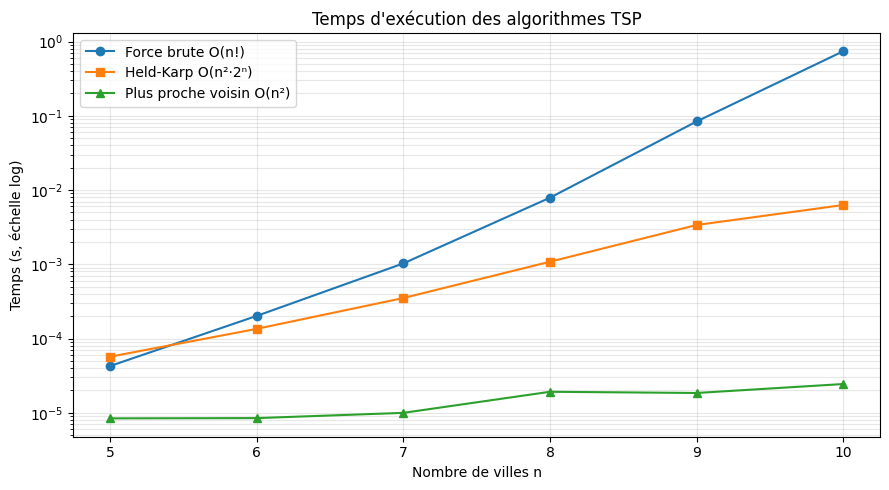

In [10]:
# Visualisation
ns = [r[0] for r in resultats]
fb = [r[1] for r in resultats]
hk = [r[2] for r in resultats]
ppv = [r[3] for r in resultats]

plt.figure(figsize=(9, 5))
plt.semilogy(ns, fb, 'o-', label='Force brute O(n!)')
plt.semilogy(ns, hk, 's-', label='Held-Karp O(n²·2ⁿ)')
plt.semilogy(ns, ppv, '^-', label='Plus proche voisin O(n²)')
plt.xlabel('Nombre de villes n')
plt.ylabel('Temps (s, échelle log)')
plt.title("Temps d'exécution des algorithmes TSP")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

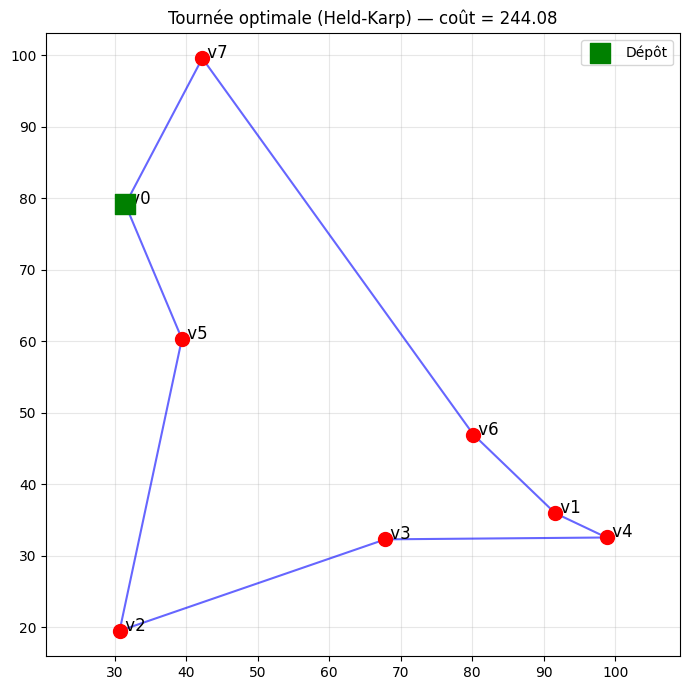

In [11]:
# Visualisation de la tournée optimale
coords8, M8 = generer_graphe_metrique(8)
tournee, cout = tsp_held_karp(M8)

plt.figure(figsize=(7, 7))
plt.scatter(coords8[:, 0], coords8[:, 1], c='red', s=100, zorder=3)
for i, (x, y) in enumerate(coords8):
    plt.annotate(f' v{i}', (x, y), fontsize=12)

xs = [coords8[i, 0] for i in tournee] + [coords8[tournee[0], 0]]
ys = [coords8[i, 1] for i in tournee] + [coords8[tournee[0], 1]]
plt.plot(xs, ys, 'b-', alpha=0.6, zorder=2)
plt.scatter(coords8[0, 0], coords8[0, 1], c='green', s=200, marker='s',
            label='Dépôt', zorder=4)
plt.title(f"Tournée optimale (Held-Karp) — coût = {cout:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

---
# 5. Contraintes supplémentaires

Le TSP métrique de base est une bonne approximation, mais le contexte ADEME (livraisons réelles) impose deux contraintes supplémentaires que nous formalisons ici.

## 5.1 Fenêtres temporelles (Time Windows)

### Motivation
Chaque ville $v_i$ a un créneau de livraison imposé par le client (ex : 8h–10h). Le véhicule doit arriver dans ce créneau, sinon la livraison échoue.

### Formalisation
On associe à chaque ville $v_i$ :
- Une fenêtre $[a_i, b_i]$ : heure d'ouverture et de fermeture
- Un temps de service $s_i \geq 0$ : durée de la livraison sur place

On note $t_i$ l'heure d'arrivée du véhicule à la ville $v_i$. Pour une tournée $\pi = (\pi_0, \pi_1, \dots, \pi_n)$ partant à $t_{\pi_0} = a_{\pi_0}$ :

$$t_{\pi_{k+1}} = \max\big(a_{\pi_{k+1}},\ t_{\pi_k} + s_{\pi_k} + w(\pi_k, \pi_{k+1})\big)$$

Le $\max$ traduit l'**attente** : si on arrive avant $a_{\pi_{k+1}}$, on attend l'ouverture.

**Contrainte de faisabilité** : pour tout $k$,
$$t_{\pi_k} \leq b_{\pi_k}$$

### Impact sur le problème
- Une instance peut devenir **infaisable** (pas seulement plus dure)
- Le problème devient **TSPTW** (TSP with Time Windows), toujours NP-difficile, mais l'asymétrie temporelle complique les heuristiques classiques (le plus proche voisin peut violer la contrainte)


### Vérificateur de faisabilité — Fenêtres temporelles

In [12]:
def verifier_tsptw(M, fenetres, services, pi):
    """
    Vérifie qu'une tournée pi respecte les fenêtres temporelles.

    M        : matrice des temps de trajet
    fenetres : liste de tuples (a_i, b_i) pour chaque ville
    services : liste des temps de service s_i
    pi       : permutation des sommets (commence par 0 = dépôt)

    Retourne (faisable, heures_arrivee, raison)
    """
    n = len(M)
    t = [0.0] * n
    t[pi[0]] = fenetres[pi[0]][0]  # départ à l\'ouverture du dépôt

    for k in range(len(pi) - 1):
        i, j = pi[k], pi[k+1]
        arrivee = t[i] + services[i] + M[i, j]
        t[j] = max(fenetres[j][0], arrivee)  # attente si trop tôt
        if t[j] > fenetres[j][1]:
            return False, t, f"Ville {j}: arrivée {t[j]:.1f} > fermeture {fenetres[j][1]:.1f}"

    # Retour au dépôt
    retour = t[pi[-1]] + services[pi[-1]] + M[pi[-1], pi[0]]
    if retour > fenetres[pi[0]][1]:
        return False, t, f"Retour dépôt: {retour:.1f} > fermeture {fenetres[pi[0]][1]:.1f}"

    return True, t, "OK"

# Exemple : 5 villes avec fenêtres
np.random.seed(0)
_, M5 = generer_graphe_metrique(5, taille=50)

fenetres = [
    (0,   200),   # dépôt : ouvert toute la journée
    (10,  60),    # ville 1
    (30,  90),    # ville 2
    (50, 120),    # ville 3
    (80, 180),    # ville 4
]
services = [0, 5, 5, 5, 5]

tournee_test = [0, 1, 2, 3, 4]
ok, heures, raison = verifier_tsptw(M5, fenetres, services, tournee_test)
print(f"Tournée {tournee_test}")
print(f"Heures d\'arrivée : {[round(h,1) for h in heures]}")
print(f"Faisable ? {ok} — {raison}")


Tournée [0, 1, 2, 3, 4]
Heures d'arrivée : [0, 10, 30, 50, np.float64(91.6)]
Faisable ? True — OK


## 5.2 Dépendances entre visites (contraintes de précédence)

### Motivation
Certaines livraisons doivent **précéder** d'autres opérations. Exemple typique : un colis doit être **livré** chez un client avant qu'on aille **collecter** sa signature ou un retour ailleurs. Plus généralement, on modélise des chaînes pickup-and-delivery.

### Formalisation
On définit un ensemble de paires ordonnées :
$$P \subseteq V \times V$$

où $(i, j) \in P$ signifie *« $i$ doit être visité avant $j$ »*.

**Contrainte** : pour toute tournée $\pi$ valide, et pour toute paire $(i, j) \in P$,
$$\text{pos}_\pi(i) < \text{pos}_\pi(j)$$

où $\text{pos}_\pi(v)$ désigne la position de $v$ dans la séquence $\pi$.

### Conditions de cohérence
- $P$ doit définir un **DAG** (graphe orienté acyclique) : sinon, présence d'un cycle de précédence $\Rightarrow$ instance trivialement infaisable
- Le dépôt $v_0$ est implicitement avant tous les autres sommets (point de départ)

### Variante connue
Cette extension correspond au **Sequential Ordering Problem (SOP)**, étudié notamment par Escudero (1988) et présent dans la TSPLIB. Toujours NP-difficile, mais la contrainte de précédence **réduit** l'espace de recherche (toutes les permutations ne sont plus admissibles), ce qui peut accélérer certaines approches en pratique.


### Vérificateur de faisabilité — Précédences

In [13]:
def verifier_precedences(pi, P):
    """
    Vérifie qu\'une tournée pi respecte les contraintes de précédence P.

    pi : permutation des sommets
    P  : liste de tuples (i, j) signifiant "i avant j"

    Retourne (faisable, violations)
    """
    position = {sommet: idx for idx, sommet in enumerate(pi)}
    violations = []
    for i, j in P:
        if position[i] >= position[j]:
            violations.append((i, j))
    return len(violations) == 0, violations


def precedences_forment_dag(P, n):
    """Vérifie que l\'ensemble P définit bien un DAG (pas de cycle)."""
    from collections import defaultdict, deque
    succ = defaultdict(list)
    deg_in = [0] * n
    for i, j in P:
        succ[i].append(j)
        deg_in[j] += 1
    file = deque([v for v in range(n) if deg_in[v] == 0])
    visites = 0
    while file:
        u = file.popleft()
        visites += 1
        for v in succ[u]:
            deg_in[v] -= 1
            if deg_in[v] == 0:
                file.append(v)
    return visites == n


# Exemple : ville 1 doit précéder ville 3, ville 2 doit précéder ville 4
P = [(1, 3), (2, 4)]

print(f"P forme un DAG ? {precedences_forment_dag(P, 5)}")

tournee_a = [0, 1, 2, 3, 4]
ok_a, viol_a = verifier_precedences(tournee_a, P)
print(f"Tournée {tournee_a} → faisable ? {ok_a}")

tournee_b = [0, 3, 1, 2, 4]
ok_b, viol_b = verifier_precedences(tournee_b, P)
print(f"Tournée {tournee_b} → faisable ? {ok_b}, violations : {viol_b}")

# Exemple de P avec cycle (infaisable)
P_cycle = [(1, 2), (2, 3), (3, 1)]
print(f"\nP_cycle forme un DAG ? {precedences_forment_dag(P_cycle, 5)}")


P forme un DAG ? True
Tournée [0, 1, 2, 3, 4] → faisable ? True
Tournée [0, 3, 1, 2, 4] → faisable ? False, violations : [(1, 3)]

P_cycle forme un DAG ? False


## 5.3 Modèle complet

En combinant les deux contraintes, le problème devient :

$$
\begin{aligned}
\min_{\pi} \quad & C(\pi) = \sum_{k=0}^{n-1} w(\pi_k, \pi_{k+1}) + w(\pi_n, \pi_0) \\
\text{s.c.} \quad & \pi \text{ est une permutation de } V \text{ avec } \pi_0 = v_0 \\
& t_{\pi_{k+1}} = \max\big(a_{\pi_{k+1}},\ t_{\pi_k} + s_{\pi_k} + w(\pi_k, \pi_{k+1})\big) \\
& a_{\pi_k} \leq t_{\pi_k} \leq b_{\pi_k} \quad \forall k \\
& \text{pos}_\pi(i) < \text{pos}_\pi(j) \quad \forall (i, j) \in P
\end{aligned}
$$

Ce problème reste **NP-difficile** (il contient le TSP métrique comme cas particulier où $b_i = +\infty$ et $P = \emptyset$), et l'ajout des contraintes peut rendre certaines instances **infaisables**.


### Vérificateur global (TSP + TW + précédences)

In [14]:
def verifier_tournee_complete(M, fenetres, services, P, pi, k_max=None):
    """
    Vérifie qu\'une tournée pi est valide selon toutes les contraintes :
    - permutation valide partant du dépôt
    - fenêtres temporelles respectées
    - précédences respectées
    - coût total <= k_max (optionnel)
    """
    n = len(M)
    rapport = {}

    # 1. Permutation valide
    if sorted(pi) != list(range(n)) or pi[0] != 0:
        return False, {"erreur": "permutation invalide"}
    rapport["permutation"] = "OK"

    # 2. Précédences
    ok_prec, violations = verifier_precedences(pi, P)
    rapport["precedences"] = "OK" if ok_prec else f"violations: {violations}"
    if not ok_prec:
        return False, rapport

    # 3. Fenêtres temporelles
    ok_tw, heures, raison_tw = verifier_tsptw(M, fenetres, services, pi)
    rapport["fenetres"] = raison_tw
    rapport["heures_arrivee"] = [round(h, 1) for h in heures]
    if not ok_tw:
        return False, rapport

    # 4. Coût
    cout = sum(M[pi[i], pi[i+1]] for i in range(n-1)) + M[pi[-1], pi[0]]
    rapport["cout"] = round(cout, 2)
    if k_max is not None and cout > k_max:
        rapport["erreur"] = f"cout {cout:.2f} > seuil {k_max}"
        return False, rapport

    return True, rapport


# Test sur un cas faisable
ok, rapport = verifier_tournee_complete(
    M5, fenetres, services,
    P=[(1, 3)],          # ville 1 avant ville 3
    pi=[0, 1, 2, 3, 4],
    k_max=300,
)
print(f"Tournée valide ? {ok}")
for cle, val in rapport.items():
    print(f"  {cle}: {val}")


Tournée valide ? True
  permutation: OK
  precedences: OK
  fenetres: OK
  heures_arrivee: [0, 10, 30, 50, np.float64(91.6)]
  cout: 94.66


---
# 6. Conclusion

| Problème | Classe | Justification |
|---|---|---|
| TSP-DEC | **NP-complet** | ∈ NP (vérification en $O(n)$) + réduction depuis HAM-CYCLE |
| TSP-OPT | **NP-difficile** | Au moins aussi dur que TSP-DEC |

**En pratique** :
- **Algorithmes exacts** (force brute, Held-Karp, B&B) : limités à $n < 20$–$25$
- **Approximations** : Christofides garantit un ratio $3/2$ pour le TSP métrique
- **Heuristiques** : plus proche voisin, insertion ($O(n^2)$, sans garantie)
- **Métaheuristiques** : recuit simulé, génétique, tabou, colonies de fourmis

## Références
1. Karp, R. M. (1972). *Reducibility among combinatorial problems*.
2. Held, M., & Karp, R. M. (1962). *A dynamic programming approach to sequencing problems*.
3. Christofides, N. (1976). *Worst-case analysis of a new heuristic for the TSP*.
4. Cormen, Leiserson, Rivest, Stein (2009). *Introduction to Algorithms*, ch. 34-35.
